# **Notebook 3: Modelling**

> **Objective:** Transform raw customer demographics and transactional basket data into a unified, model-ready master dataset. Heavy lifting and pipeline steps are modularly executed via our centralized `datacleaning.py` script.

---

## **Table of Contents**
1. [Imports and Libraries](#1-imports)
2. [Load Raw Datasets](#2-load)
3. [Execute Independent Cleaning Pipelines](#3-pipelines)
4. [Merging the Two Clean Datasets (Inner Join)](#4-merge)
5. [Validation Checks](#5-validation)
6. [Export Final Data](#6-export)

---

## **Imports and Libraries**

In [1]:
import sys
sys.path.append('../src')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.metrics import silhouette_score, silhouette_samples, confusion_matrix, adjusted_rand_score
from datacleaning import customer_handle_missing_values


from utils import (
    scaling,
    plot_dendrogram,
    visualize_dimensionality_reduction
)


from clustering import(
    plot_silhouette_kmeans,
    plot_silhouette_hierarchical,
    plot_elbow,
    print_silhouette_scores,
    apply_kmeans_perc,
    apply_kmeans_lifetime,
    apply_hierarchical_perc,
    apply_hierarchical_lifetime,
    cluster_groupby,
    dendrogram_visualization
)

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = pd.read_csv('../data/clean_customer_info.csv', index_col= 0)

dataset.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,year_first_transaction,years_tenure,distinct_stores_visited,...,perc_spend_vegetables,perc_spend_meat_fish,perc_spend_petfood,perc_spend_tech_entertainment,perc_spend_groceries,perc_spend_alcohol,perc_spend_hygiene,latitude,longitude,is_customer_outlier
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,2020,6,3,...,0.020065,0.012964,0.020656,0.258687,0.631038,0.009521,0.029693,38.794428,-9.215739,0
4,Glenda Bauman,female,51,Bsc,1,0,1,2013,13,2,...,0.099442,0.002867,0.032867,0.064054,0.676815,0.004695,0.092918,38.751711,-9.179611,0
5,Antonio Campbell,male,55,Msc,0,0,0,2005,21,2,...,0.035694,0.098913,0.014277,0.006496,0.797929,0.007589,0.032607,38.780678,-9.160656,0
7,John Kelling,male,44,Unknown,0,0,0,2021,5,1,...,0.005618,0.137440,0.012306,0.184658,0.501137,0.075776,0.032437,38.739548,-9.148679,0
8,Arthur Dematteo,male,57,Unknown,0,0,0,2021,5,1,...,0.014730,0.080746,0.017095,0.469008,0.356127,0.027833,0.011513,38.733071,-9.188188,0


## **2. Clustering with percentages**

### **2.1. Feature Selection and Pre-Processing**

Regarding the features we used for the clustering, after **several tries with different combinations**, we ended up choosing the ones in the cell below. 

This section contemplates both demographic variables (`customer_age`, `total_children`, `years_tenure`) and behavioral metrics (`spend percentages`, `number_complaints`, `percentage_of_products_bought_promotion`). This approach allows the K-Means algorithm to capture and differentiate customers with similar shopping tendencies but with different life stages. 

##### **2.1.1 'Lifetime Spend' vs Percentage Spend**
A critical data engineering decision was to utilize relative **percentage spending instead of absolute lifetime spend** metrics (e.g., using perc_spend_vegetables rather than lifetime_spend_vegetables).

If absolute values had been used, the K-Means would be biased by overall purchasing power, simply dividing the database into "Rich Customers" vs. "Poor Customers". By converting the data into percentages, we "normalize" the shopping basket. This forces the algorithm to group customers based on their lifestyle preferences and tastes (e.g., identifying a strict Vegetarian), regardless of whether their total budget is large or small. 

##### **2.1.2 Removing Uninformative Categories**

Some features were purposely **excluded** from the final feature selection like, the groceries, pet food and alcohol. After several tries to improve our clustering, these variables showed **low variance or no pattern across our customers**. They would act more as statistical **noise** rather than differentiating factors, that way, the algortihm only focuses on the features that truly segmentate our customers.


Geospatial variables (latitude, longitude) were also **excluded** to prevent the model from creating regional bias, reserving them for later profiling.

In [3]:
dataset_perc = dataset.copy()

In [4]:
features_perc = [
    'customer_age',
    'number_complaints',
    'kids_home',
    'teens_home',

    'percentage_of_products_bought_promotion',
    'perc_spend_vegetables',
    'perc_spend_meat_fish',
    'perc_spend_tech_entertainment',
    'perc_spend_hygiene'
]

X_perc = dataset_perc[features_perc].copy()
X_perc.columns

Index(['customer_age', 'number_complaints', 'kids_home', 'teens_home',
       'percentage_of_products_bought_promotion', 'perc_spend_vegetables',
       'perc_spend_meat_fish', 'perc_spend_tech_entertainment',
       'perc_spend_hygiene'],
      dtype='object')

##### **2.1.3 Data Scaling**

The data was normalized using **StandardScaler**. Without standardization, features with larger numerical ranges (e.g., `customer_age` or `years_tenure`) would **disproportionately dominate** the distance calculations, lowering the impact of bounded features (such as `percentage_of_products_bought_promotion`, which strictly ranges from 0 to 1).



In [5]:
X_scaled_perc = scaling(X_perc) #Standard Scaler

## **2.2 Determining the Optimal Number of Clusters (K)**

To determine the optimal number of clusters($K$), two strategies were used: the **Elbow Method** and the **Silhouette Score**.

#### **3.1. Elbow Method**

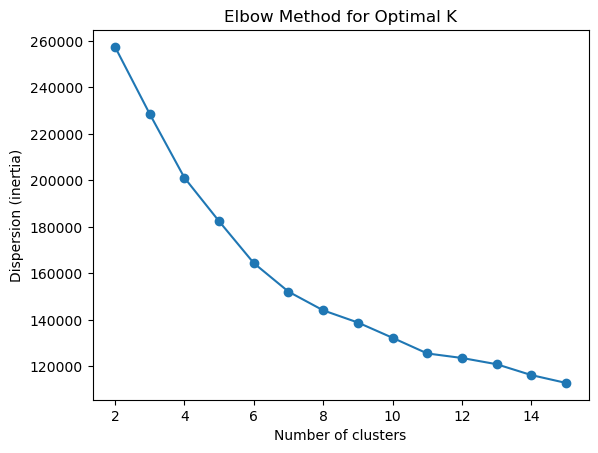

In [6]:
plot_elbow(X_scaled_perc, k_range= 15)

The Elbow Method evaluates the **inertia** to measure cluster compactness. 
As observed in the plot, the inertia decreases smoothly **without** an "elbow" point. This indicates that while the variance continues to drop as K increases, the marginal gain diminishes after the mid-range values.

With all this information, theoretically, the "best" numbers of $K$ would maybe be between 8-10.

##### **3.2. Silhouette Score**

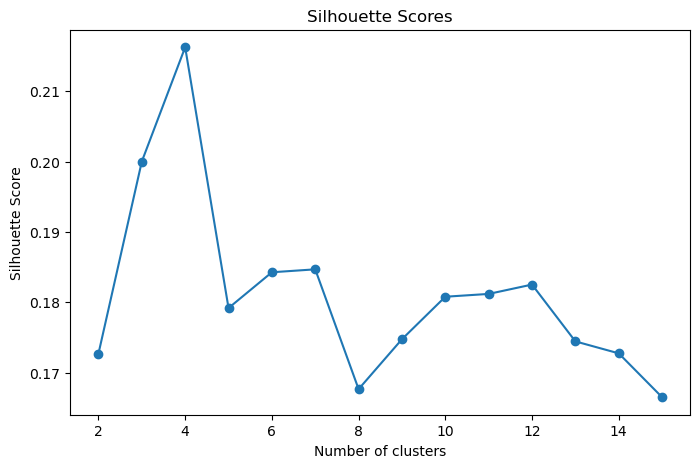

Evaluating Silhouette Scores:
k=7 | silhouette=0.1809
k=8 | silhouette=0.1663
k=9 | silhouette=0.1743
k=10 | silhouette=0.1799


In [7]:
plot_silhouette_kmeans(X_scaled_perc)
print_silhouette_scores(X_scaled_perc, k_values= [7,8,9,10])

The Silhouette Score measures **cluster cohesion**. The plot demonstrates a mathematical peak at lower values (e.g., K=2). However, we decided that selecting K=2 would result in severe **under-fitting**, as it would not be appropriate to divide the whole dataset in just 2 groups.

Although $K$ = 7 was the second best score, by looking at our customer data and after many analysis we conclude that choosing 7 clusters would create **under-segmentation** (e.g. the Vegetarians and the Hygiene were overlapping). Therefore, we chose **$K$** = 9 as our final choice.

## **4. K-Means Algorithm**

##### **4.1. How it Works**

The first algorithm we used was **K-Means**. Mathematically, it starts by defining $K$ centroids (the central points) in the data space. Then, assigns every customer to the centroid that most closely matches their unique purchasing habits. Through continuous iteration, the algorithm refines these groups until it achieves **maximum similarity inside** each cluster and **maximum variance between** clusters.

By setting the model to **$K=9$**, as defined before, the algorithm identifies nine different profiles that exist in the dataset.

In [6]:
X_scaled_perc = pd.DataFrame(X_scaled_perc, columns=X_perc.columns, index=X_perc.index)

apply_kmeans_perc(X_scaled_perc, dataset_perc, X_perc, k = 9)

Customer Distribution for K=9:
cluster_kmeans_perc
0    5396
1    6189
2    2884
3    3655
4    2935
5    2929
6    1638
7    5034
8    2378
Name: count, dtype: int64


,n_clusters,9
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [7]:
cluster_groupby(X_scaled_perc, cluster_kmeans= 'cluster_kmeans_perc', method= 'mean')

Grouped by mean


cluster_kmeans_perc,0,1,2,3,4,5,6,7,8
customer_age,-0.818632,0.983967,0.139010,-0.618763,0.113713,0.125827,0.236501,-0.244136,0.137736
number_complaints,-0.532725,-0.314885,-0.185057,1.696933,0.166135,-0.415915,-0.046947,0.011843,-0.040910
kids_home,-0.335457,-0.243325,-0.069064,0.511820,-0.757532,-0.051695,-0.291503,-0.235863,2.390301
teens_home,-0.135761,-0.074754,0.009469,-0.091198,-0.615397,-0.050597,-0.137771,-0.357775,2.305439
percentage_of_products_bought_promotion,-0.435969,-0.275911,-0.787800,0.041769,-0.228678,-0.605422,0.429002,1.773496,-0.423289
perc_spend_vegetables,-0.319169,-0.316785,2.177690,-0.426991,-0.647324,1.054222,0.264141,-0.358870,-0.357873
perc_spend_meat_fish,-0.097851,-0.122994,-1.067691,0.106642,0.293100,-0.914472,2.746372,0.095172,0.344507
perc_spend_tech_entertainment,-0.357815,-0.375534,0.221700,-0.316566,2.617849,-0.491958,0.187059,-0.418123,0.138182
perc_spend_hygiene,-0.230301,-0.256677,0.232893,-0.303063,-0.768169,2.182423,1.001759,-0.308332,-0.403350


In [8]:
cluster_groupby(X_perc, cluster_kmeans= 'cluster_kmeans_perc', method= 'mean')

Grouped by mean


cluster_kmeans_perc,0,1,2,3,4,5,6,7,8
customer_age,40.336916,72.845856,57.607490,43.941450,57.151278,57.369751,59.365690,50.697656,57.584525
number_complaints,0.457376,0.651155,0.766644,2.440766,1.079046,0.561284,0.889499,0.941796,0.894870
kids_home,0.731653,0.837292,1.037101,1.703146,0.247700,1.057016,0.782051,0.845848,3.857023
teens_home,0.768718,0.827274,0.908114,0.811491,0.308348,0.850461,0.766789,0.555622,3.111859
percentage_of_products_bought_promotion,0.203039,0.246775,0.106899,0.333582,0.259681,0.156735,0.439395,0.806783,0.206503
perc_spend_vegetables,0.025125,0.025250,0.155753,0.019484,0.007957,0.096977,0.055642,0.023048,0.023101
perc_spend_meat_fish,0.057459,0.056269,0.011560,0.067136,0.075961,0.018811,0.192065,0.066594,0.078394
perc_spend_tech_entertainment,0.081726,0.079214,0.163884,0.087574,0.503586,0.062708,0.158973,0.073176,0.152043
perc_spend_hygiene,0.033285,0.032207,0.052211,0.030311,0.011307,0.131871,0.083628,0.030096,0.026214


In [9]:
numeric_cols_perc = dataset_perc.select_dtypes(include='number')

cluster_groupby(numeric_cols_perc, cluster_kmeans= 'cluster_kmeans_perc', method= 'mean').T

Grouped by mean


,customer_age,kids_home,teens_home,total_children,year_first_transaction,years_tenure,distinct_stores_visited,number_complaints,typical_hour,lifetime_total_distinct_products,...,perc_spend_vegetables,perc_spend_meat_fish,perc_spend_petfood,perc_spend_tech_entertainment,perc_spend_groceries,perc_spend_alcohol,perc_spend_hygiene,latitude,longitude,is_customer_outlier
cluster_kmeans_perc,,,,,,,,,,,,,,,,,,,,,
0,40.336916,0.731653,0.768718,1.500371,2015.494626,10.505374,3.076723,0.457376,12.186064,164.272239,...,0.025125,0.057459,0.015268,0.081726,0.743901,0.025487,0.033285,38.748027,-9.153987,0.000741
1,72.845856,0.837292,0.827274,1.664566,2013.453870,12.546130,3.357570,0.651155,11.888512,179.232186,...,0.025250,0.056269,0.014893,0.079214,0.754054,0.020420,0.032207,38.749352,-9.154078,0.000646
2,57.607490,1.037101,0.908114,1.945215,2014.568308,11.431692,3.227115,0.766644,14.057559,82.997226,...,0.155753,0.011560,0.019962,0.163884,0.533696,0.030934,0.052211,38.747137,-9.156274,0.000000
3,43.941450,1.703146,0.811491,2.514637,2015.996717,10.003283,2.694118,2.440766,11.236389,116.467852,...,0.019484,0.067136,0.017548,0.087574,0.723864,0.036460,0.030311,38.748726,-9.157005,0.001094
4,57.151278,0.247700,0.308348,0.556048,2017.015332,8.984668,1.506644,1.079046,17.407836,110.647700,...,0.007957,0.075961,0.013459,0.503586,0.316034,0.046989,0.011307,38.748836,-9.172088,0.001704
5,57.369751,1.057016,0.850461,1.907477,2016.256402,9.743598,3.575623,0.561284,10.879822,122.363264,...,0.096977,0.018811,0.026215,0.062708,0.611878,0.012462,0.131871,38.761644,-9.131079,0.000000
6,59.365690,0.782051,0.766789,1.548840,2014.401709,11.598291,3.597070,0.889499,12.839438,148.335165,...,0.055642,0.192065,0.042619,0.158973,0.376895,0.048692,0.083628,38.749300,-9.156490,0.000611
7,50.697656,0.845848,0.555622,1.401470,2015.575089,10.424911,3.894120,0.941796,13.785260,124.453119,...,0.023048,0.066594,0.017565,0.073176,0.748942,0.024854,0.030096,38.748450,-9.154985,0.001192
8,57.584525,3.857023,3.111859,6.968881,2012.862489,13.137511,3.231707,0.894870,10.158957,297.091674,...,0.023101,0.078394,0.010493,0.152043,0.643286,0.043061,0.026214,38.748197,-9.156186,0.004205


In [ ]:
cluster_names = {
    0: "Older Long-Tenure",
    1: "Large Families",
    2: "Clean and Green",
    3: 'Young Most Recent Customer',
    4: "Tech Enthusiasts",
    5: "Promotion Seekers",
    6: "Protein Lovers",
    7: "Service Sensitive"
}


dataset['cluster_name'] = dataset['cluster_kmeans_perc'].map(cluster_names)
dataset.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,year_first_transaction,years_tenure,distinct_stores_visited,...,perc_spend_petfood,perc_spend_tech_entertainment,perc_spend_groceries,perc_spend_alcohol,perc_spend_hygiene,latitude,longitude,is_customer_outlier,cluster_kmeans,cluster_name
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,2020,6,3,...,0.020656,0.258687,0.631038,0.009521,0.029693,38.794428,-9.215739,0,3,Young Most Recent Customer
4,Glenda Bauman,female,51,Bsc,1,0,1,2013,13,2,...,0.032867,0.064054,0.676815,0.004695,0.092918,38.751711,-9.179611,0,2,Clean and Green
5,Antonio Campbell,male,55,Msc,0,0,0,2005,21,2,...,0.014277,0.006496,0.797929,0.007589,0.032607,38.780678,-9.160656,0,0,Older Long-Tenure
7,John Kelling,male,44,Unknown,0,0,0,2021,5,1,...,0.012306,0.184658,0.501137,0.075776,0.032437,38.739548,-9.148679,0,7,Service Sensitive
8,Arthur Dematteo,male,57,Unknown,0,0,0,2021,5,1,...,0.017095,0.469008,0.356127,0.027833,0.011513,38.733071,-9.188188,0,4,Tech Enthusiasts


## **5. Hierarchical Clustering**

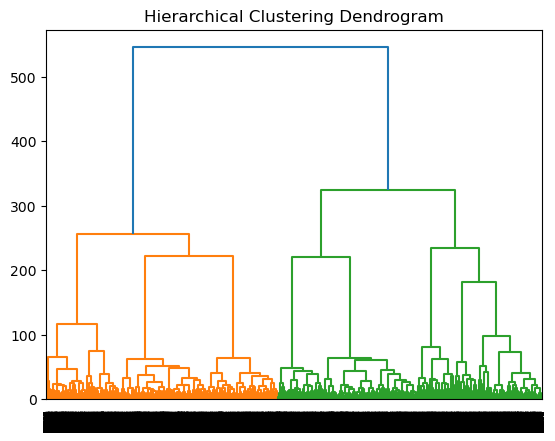

In [8]:
dendrogram_visualization(X_scaled_perc)

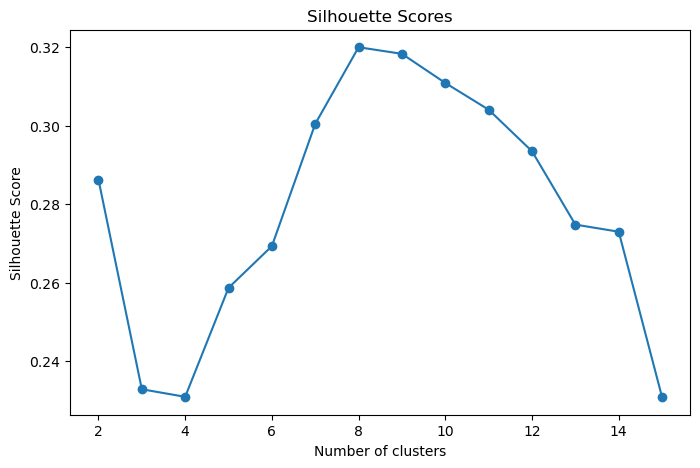

In [9]:
plot_silhouette_hierarchical(X_scaled_perc)

In [10]:
apply_hierarchical_perc(X_scaled_perc, dataset_perc, X_perc, k = 9)

Customer Distribution for K=9:
cluster_agglomerative_perc
0    3627
1    2942
2    2922
3    6558
4    2384
5    2939
6    5027
7    1649
8    4990
Name: count, dtype: int64


,n_clusters,9
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [12]:
pd.DataFrame(
    confusion_matrix(
        dataset_perc['cluster_kmeans_perc'],
        dataset_perc['cluster_agglomerative_perc']
    ),
    index=[f'K-Means {i} Cluster' for i in np.arange(0, 9)],
    columns=[f'Hierarchical {i} Cluster' for i in np.arange(0, 9)]
)

,Hierarchical 0 Cluster,Hierarchical 1 Cluster,Hierarchical 2 Cluster,Hierarchical 3 Cluster,Hierarchical 4 Cluster,Hierarchical 5 Cluster,Hierarchical 6 Cluster,Hierarchical 7 Cluster,Hierarchical 8 Cluster
K-Means 0 Cluster,0,0,0,408,0,0,0,0,4988
K-Means 1 Cluster,0,38,0,6149,0,0,0,0,2
K-Means 2 Cluster,4,2879,0,1,0,0,0,0,0
K-Means 3 Cluster,3605,25,0,0,0,23,0,2,0
K-Means 4 Cluster,18,0,1,0,0,2916,0,0,0
K-Means 5 Cluster,0,0,2921,0,0,0,0,8,0
K-Means 6 Cluster,0,0,0,0,9,0,23,1606,0
K-Means 7 Cluster,0,0,0,0,0,0,5001,33,0
K-Means 8 Cluster,0,0,0,0,2375,0,3,0,0


In [13]:
ari = adjusted_rand_score(
    dataset_perc['cluster_kmeans_perc'],
    dataset_perc['cluster_agglomerative_perc']
)

print("Adjusted Rand Index:", round(ari, 3))

Adjusted Rand Index: 0.952


In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    random_state=0
)

tsne_transformation = tsne.fit_transform(X_scaled_perc)


c:\Users\laura\Desktop\ML II\ml_project\notebooks\../src\utils.py:85: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


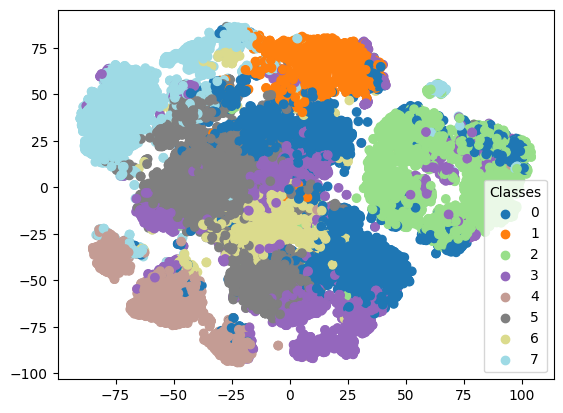

In [ ]:
visualize_dimensionality_reduction(tsne_transformation, dataset_perc['cluster_kmeans_perc'])    


In [ ]:
umap = UMAP(n_neighbors=50, random_state=0)

umap_transformation = umap.fit_transform(X_scaled_perc)

c:\Users\laura\Desktop\ML II\ml_project\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
visualize_dimensionality_reduction(umap_transformation, dataset_perc['cluster_kmeans_perc'])

NameError: name 'umap_transformation' is not defined

## **3. Clustering with lifetime spend values**

In [14]:
dataset_lifetime = dataset.copy()

In [15]:
features_lifetime = [
    'customer_age',
    'number_complaints',
    'kids_home',
    'teens_home',

    'percentage_of_products_bought_promotion',
    'lifetime_spend_vegetables',
    'lifetime_spend_meat_fish',
    'lifetime_spend_electronics',
    'lifetime_spend_videogames',
    'lifetime_spend_hygiene',
    'lifetime_spend_alcohol_drinks',
]

X_lifetime = dataset_lifetime[features_lifetime].copy()  
X_lifetime.columns

Index(['customer_age', 'number_complaints', 'kids_home', 'teens_home',
       'percentage_of_products_bought_promotion', 'lifetime_spend_vegetables',
       'lifetime_spend_meat_fish', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_hygiene',
       'lifetime_spend_alcohol_drinks'],
      dtype='object')

In [16]:
X_scaled_lifetime = scaling(X_lifetime) #Standard Scaler

### **3.1 Determining the Optimal Number of Clusters (K)**

#### **3.1.1. Elbow Method**

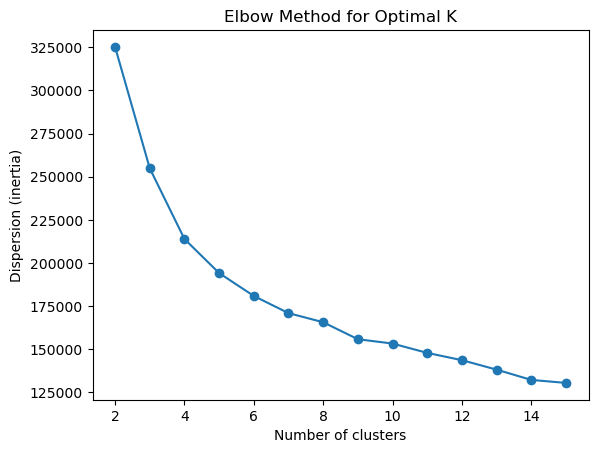

In [ ]:
plot_elbow(X_scaled_lifetime, k_range= 15)

#### **3.1.2 Silhouette Score**

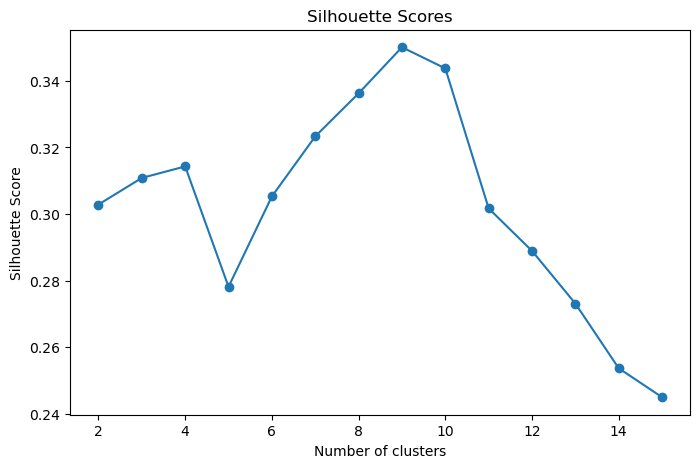

Evaluating Silhouette Scores:
k=7 | silhouette=0.3242
k=8 | silhouette=0.3376
k=9 | silhouette=0.3506
k=10 | silhouette=0.3430


In [ ]:
plot_silhouette_kmeans(X_scaled_lifetime)
print_silhouette_scores(X_scaled_lifetime, k_values= [7,8,9,10])

### **3.2 K-Means Algorithm**

In [17]:
X_scaled_lifetime = pd.DataFrame(X_scaled_lifetime, columns=X_lifetime.columns, index=X_lifetime.index)

apply_kmeans_lifetime(X_scaled_lifetime, dataset_lifetime, X_lifetime, k = 9)

Customer Distribution for K=9:
cluster_kmeans_lifetime
0    3661
1    4939
2    1168
3    6788
4    3278
5    3286
6    2881
7    3249
8    3788
Name: count, dtype: int64


,n_clusters,9
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [18]:
cluster_groupby(X_scaled_lifetime,cluster_kmeans= 'cluster_kmeans_lifetime', method= 'mean')

Grouped by mean


cluster_kmeans_lifetime,0,1,2,3,4,5,6,7,8
customer_age,0.150369,0.066008,0.643677,0.073508,0.090507,-1.193887,0.111253,0.111179,0.215784
number_complaints,-0.196014,-0.258223,2.794327,-0.571588,0.152721,1.085122,-0.062808,-0.444499,0.044333
kids_home,-0.069738,-0.450524,0.189790,-0.435861,-0.744484,0.610145,2.095728,-0.060083,-0.050078
teens_home,0.003036,-0.389884,0.491434,-0.196703,-0.604198,-0.354215,2.043525,-0.034931,0.012237
percentage_of_products_bought_promotion,-0.791204,1.586455,-0.020083,-0.541364,-0.232202,0.615353,-0.436585,-0.607856,0.193022
lifetime_spend_vegetables,1.965689,-0.438182,-0.259991,-0.324376,-0.806926,-0.701055,0.172426,1.177723,-0.501869
lifetime_spend_meat_fish,-1.292362,-0.179951,0.419992,0.039920,0.498311,-0.357720,1.685116,-1.162994,0.877597
lifetime_spend_electronics,-0.215393,-0.483672,-0.243998,-0.451145,2.139071,-0.455338,0.652046,-0.546911,0.239573
lifetime_spend_videogames,-0.292834,-0.284404,-0.252918,-0.345376,2.517798,-0.461873,0.099512,-0.482966,-0.088861
lifetime_spend_hygiene,-0.187923,-0.560958,-0.114710,-0.205617,-0.897865,-0.610027,0.138180,1.982470,0.817550


In [19]:
cluster_groupby(X_lifetime,cluster_kmeans= 'cluster_kmeans_lifetime', method= 'mean')

Grouped by mean


cluster_kmeans_lifetime,0,1,2,3,4,5,6,7,8
customer_age,57.812346,56.290950,66.708904,56.426193,56.732764,33.569385,57.106907,57.105571,58.992080
number_complaints,0.756897,0.701559,3.416952,0.422805,1.067114,1.896531,0.875390,0.535857,0.970697
kids_home,1.036329,0.599717,1.333904,0.616529,0.262660,1.815886,3.519264,1.047399,1.058870
teens_home,0.901939,0.524803,1.370719,0.710224,0.319097,0.559038,2.860465,0.865497,0.910771
percentage_of_products_bought_promotion,0.105969,0.755673,0.316681,0.174239,0.258718,0.490316,0.202870,0.156070,0.374913
lifetime_spend_vegetables,2002.151871,425.230006,542.121575,499.885386,183.336181,252.786671,825.784103,1485.252078,383.451690
lifetime_spend_meat_fish,163.468451,1141.543025,1669.035103,1334.861815,1737.896278,985.241631,2781.380423,277.213912,2071.378828
lifetime_spend_electronics,1966.794592,1043.849970,1868.386986,1155.747790,10066.725442,1141.324711,4950.997570,826.292090,3531.989440
lifetime_spend_videogames,231.969134,235.839846,250.296233,207.845315,1522.434411,154.356969,412.109684,144.672515,325.620908
lifetime_spend_hygiene,697.381043,469.555781,742.095034,686.574838,263.794692,439.587340,896.543561,2022.916590,1311.458817


In [32]:
cluster_names = {
    0: "Average",
    1: "Promotion seeker",
    2: "Green screen",
    3: 'Large Families',
    4: "Promotion seekers",
    5: "Tech-enthusiasts",
    6: "Clean and green",
    7: "Meetfish",
    8: "Karens"
}


dataset_lifetime['cluster_name'] = dataset_lifetime['cluster_kmeans_lifetime'].map(cluster_names)
dataset_lifetime.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,year_first_transaction,years_tenure,distinct_stores_visited,...,perc_spend_tech_entertainment,perc_spend_groceries,perc_spend_alcohol,perc_spend_hygiene,latitude,longitude,is_customer_outlier,cluster_kmeans_lifetime,cluster_agglomerative_lifetime,cluster_name
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,2020,6,3,...,0.258687,0.631038,0.009521,0.029693,38.794428,-9.215739,0,1,0,Promotion seeker
4,Glenda Bauman,female,51,Bsc,1,0,1,2013,13,2,...,0.064054,0.676815,0.004695,0.092918,38.751711,-9.179611,0,7,7,Meetfish
5,Antonio Campbell,male,55,Msc,0,0,0,2005,21,2,...,0.006496,0.797929,0.007589,0.032607,38.780678,-9.160656,0,3,6,Large Families
7,John Kelling,male,44,Unknown,0,0,0,2021,5,1,...,0.184658,0.501137,0.075776,0.032437,38.739548,-9.148679,0,4,2,Promotion seekers
8,Arthur Dematteo,male,57,Unknown,0,0,0,2021,5,1,...,0.469008,0.356127,0.027833,0.011513,38.733071,-9.188188,0,4,8,Promotion seekers


### **3.3 Hierarchical Algorithm**

In [ ]:
dendrogram_visualization(X_scaled_lifetime)

In [ ]:
plot_silhouette_hierarchical(X_scaled_lifetime)

In [20]:
apply_hierarchical_lifetime(X_scaled_lifetime, dataset_lifetime, X_lifetime, k = 9)

Customer Distribution for K=9:
cluster_agglomerative_lifetime
0    5135
1    2896
2    3458
3    3655
4    3861
5    3271
6    6392
7    3175
8    1195
Name: count, dtype: int64


,n_clusters,9
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [21]:
pd.DataFrame(
    confusion_matrix(
        dataset_lifetime['cluster_kmeans_lifetime'],
        dataset_lifetime['cluster_agglomerative_lifetime']
    ),
    index=[f'K-Means {i} Cluster' for i in np.arange(0, 9)],
    columns=[f'Hierarchical {i} Cluster' for i in np.arange(0, 9)]
)

,Hierarchical 0 Cluster,Hierarchical 1 Cluster,Hierarchical 2 Cluster,Hierarchical 3 Cluster,Hierarchical 4 Cluster,Hierarchical 5 Cluster,Hierarchical 6 Cluster,Hierarchical 7 Cluster,Hierarchical 8 Cluster
K-Means 0 Cluster,6,0,0,3655,0,0,0,0,0
K-Means 1 Cluster,4854,0,81,0,0,0,0,0,4
K-Means 2 Cluster,3,0,0,0,0,0,10,0,1155
K-Means 3 Cluster,271,0,135,0,0,0,6382,0,0
K-Means 4 Cluster,1,0,3240,0,0,1,0,0,36
K-Means 5 Cluster,0,14,2,0,0,3270,0,0,0
K-Means 6 Cluster,0,2881,0,0,0,0,0,0,0
K-Means 7 Cluster,0,0,0,0,74,0,0,3175,0
K-Means 8 Cluster,0,1,0,0,3787,0,0,0,0


In [22]:
ari = adjusted_rand_score(
    dataset_lifetime['cluster_kmeans_lifetime'],
    dataset_lifetime['cluster_agglomerative_lifetime']
)

print("Adjusted Rand Index:", round(ari, 3))

Adjusted Rand Index: 0.95


In [23]:
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    random_state=0
)

tsne_transformation = tsne.fit_transform(X_scaled_lifetime)

c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:85: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


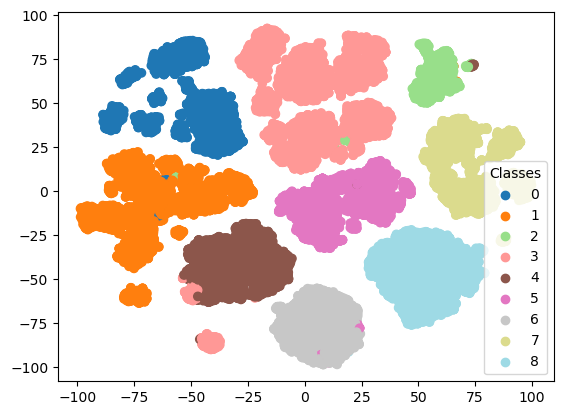

In [25]:
visualize_dimensionality_reduction(tsne_transformation, dataset_lifetime['cluster_kmeans_lifetime'])    


In [26]:
umap = UMAP(n_neighbors=50, random_state=0)



umap_transformation = umap.fit_transform(X_scaled_lifetime)

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:85: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


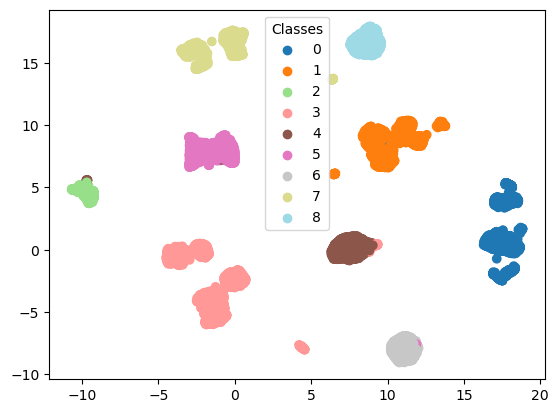

In [27]:
visualize_dimensionality_reduction(umap_transformation, dataset_lifetime['cluster_kmeans_lifetime'])

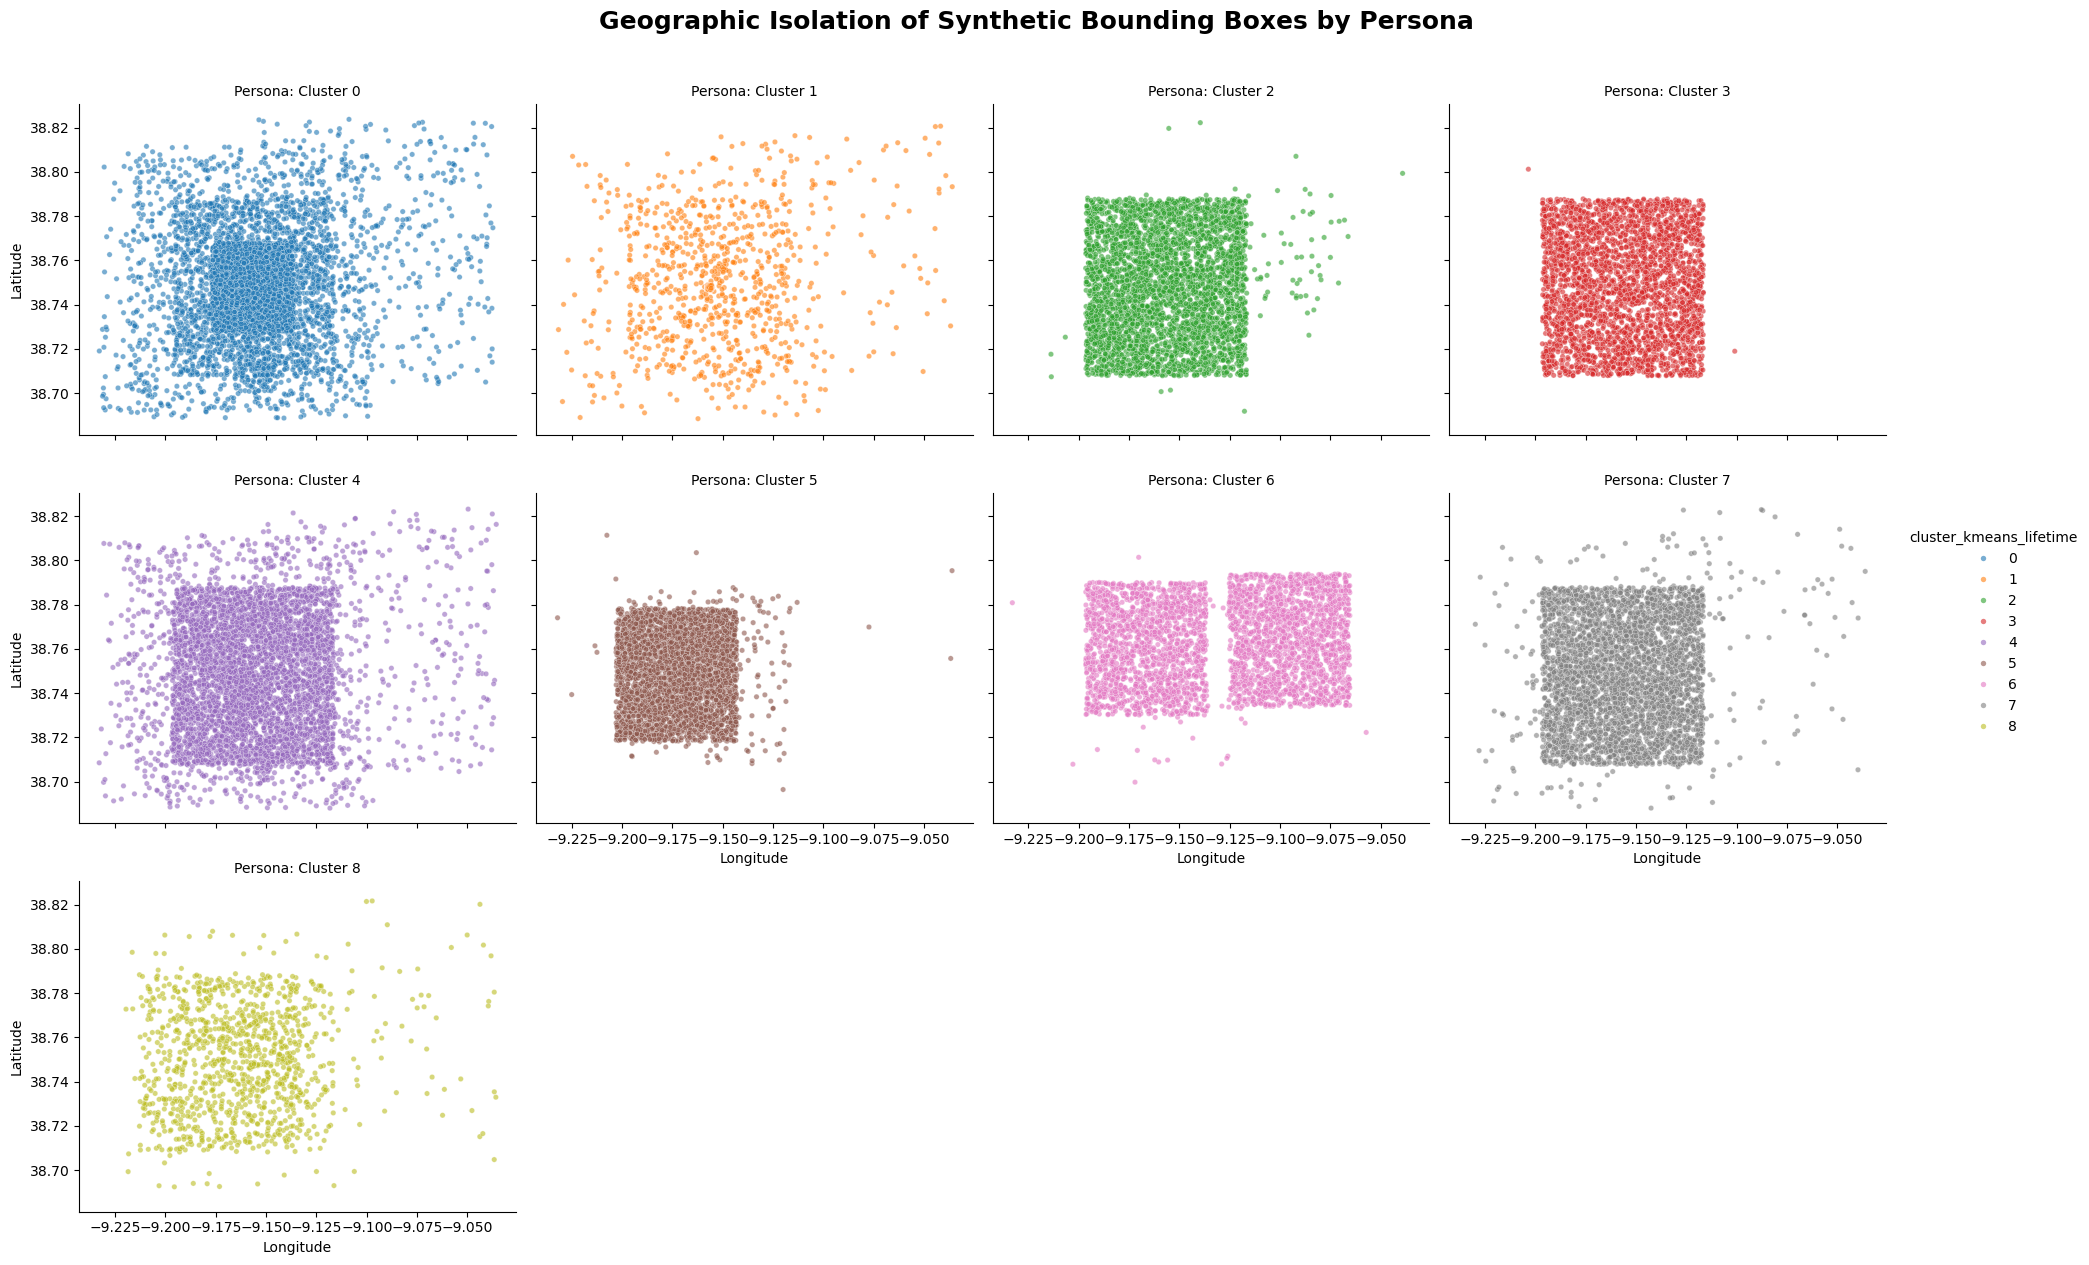

In [ ]:
# Using relplot to create a grid: one map per cluster
g = sns.relplot(
    data=dataset_lifetime,
    x='longitude',
    y='latitude',
    col='cluster_kmeans_lifetime', # This splits the data into separate plots!
    col_wrap=4,           # Defines 4 maps per row
    hue='cluster_kmeans_lifetime',
    palette='tab10',
    s=15,                 # Dot size
    alpha=0.6,            # Transparency
    height=4,             # Height of each individual map
    aspect=1.2            # Width ratio
)

# Formatting for the university report
g.fig.suptitle('Geographic Isolation of Synthetic Bounding Boxes by Persona', y=1.05, fontsize=18, fontweight='bold')
g.set_axis_labels('Longitude', 'Latitude')
g.set_titles('Persona: Cluster {col_name}') # Names each subplot automatically

plt.show()

In [28]:
dataset_export = dataset_lifetime.reset_index()

In [31]:
customer_clusters = dataset_export[['customer_id', 'cluster_kmeans_lifetime', 'cluster_name']].copy()

customer_clusters.to_csv("../data/customer_clusters.csv", index=False)

KeyError: "['cluster_name'] not in index"